<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Gradients and Optimizers in QML

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `3.2`.


## Common setup

The following cell reproduces the base imports, variational model, gradient helpers, budget helpers, and optimizer utilities used in the main notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pennylane as qml
from scipy.optimize import minimize
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)


ANALYTIC_DEVICE = qml.device("default.qubit", wires=2)


def variational_circuit(x, weights):
    qml.RY(float(x[0]), wires=0)
    qml.RY(float(x[1]), wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(float(weights[0]), wires=0)
    qml.RY(float(weights[1]), wires=1)
    qml.CNOT(wires=[1, 0])
    qml.RY(float(weights[2]), wires=0)
    qml.RY(float(weights[3]), wires=1)


@qml.qnode(ANALYTIC_DEVICE)
def analytic_score_qnode(x, weights):
    variational_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))


def exact_score(x, weights):
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return float(analytic_score_qnode(x, weights))


def batch_scores(samples, weights):
    return np.array([exact_score(x, weights) for x in samples], dtype=float)


def probabilities_from_scores(scores, eps=1e-9):
    probabilities = (1.0 + np.asarray(scores, dtype=float)) / 2.0
    return np.clip(probabilities, eps, 1.0 - eps)


def binary_cross_entropy_per_sample(labels, probabilities):
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return -(labels * np.log(probabilities) + (1.0 - labels) * np.log(1.0 - probabilities))


def mean_binary_cross_entropy(samples, labels, weights):
    scores = batch_scores(samples, weights)
    probabilities = probabilities_from_scores(scores)
    return float(np.mean(binary_cross_entropy_per_sample(labels, probabilities)))


def bce_score_derivative(labels, probabilities):
    labels = np.asarray(labels, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    return 0.5 * (-labels / probabilities + (1.0 - labels) / (1.0 - probabilities))


def forward_difference_gradient(samples, labels, weights, eps):
    weights = np.asarray(weights, dtype=float)
    gradient = np.zeros_like(weights)
    baseline = mean_binary_cross_entropy(samples, labels, weights)
    for m in range(len(weights)):
        shifted = weights.copy()
        shifted[m] += eps
        gradient[m] = (mean_binary_cross_entropy(samples, labels, shifted) - baseline) / eps
    return gradient


def central_difference_gradient(samples, labels, weights, eps):
    weights = np.asarray(weights, dtype=float)
    gradient = np.zeros_like(weights)
    for m in range(len(weights)):
        plus = weights.copy()
        minus = weights.copy()
        plus[m] += eps
        minus[m] -= eps
        gradient[m] = (
            mean_binary_cross_entropy(samples, labels, plus)
            - mean_binary_cross_entropy(samples, labels, minus)
        ) / (2.0 * eps)
    return gradient


def parameter_shift_score_jacobian(samples, weights, shift=np.pi / 2):
    samples = np.asarray(samples, dtype=float)
    weights = np.asarray(weights, dtype=float)
    jacobian = np.zeros((len(samples), len(weights)))
    for m in range(len(weights)):
        plus = weights.copy()
        minus = weights.copy()
        plus[m] += shift
        minus[m] -= shift
        s_plus = batch_scores(samples, plus)
        s_minus = batch_scores(samples, minus)
        jacobian[:, m] = 0.5 * (s_plus - s_minus)
    return jacobian


def parameter_shift_bce_gradient(samples, labels, weights):
    scores = batch_scores(samples, weights)
    probabilities = probabilities_from_scores(scores)
    score_jacobian = parameter_shift_score_jacobian(samples, weights)
    sample_derivatives = bce_score_derivative(labels, probabilities)
    return score_jacobian.T @ sample_derivatives / len(samples)


def make_shot_score_qnode(shots, seed):
    shot_device = qml.device("default.qubit", wires=2, seed=int(seed))

    @qml.qnode(shot_device)
    def shot_score_qnode(x, weights):
        variational_circuit(x, weights)
        return qml.expval(qml.PauliZ(0))

    return qml.set_shots(shot_score_qnode, shots=int(shots))


def shot_based_z_score(x, weights, shots, rng):
    seed = int(rng.integers(0, 2**31 - 1))
    shot_score_qnode = make_shot_score_qnode(shots=shots, seed=seed)
    return float(shot_score_qnode(np.asarray(x, dtype=float), np.asarray(weights, dtype=float)))


def parameter_shift_shot_score_derivative(x, weights, param_index, shots, rng, shift=np.pi / 2):
    plus = np.asarray(weights, dtype=float).copy()
    minus = np.asarray(weights, dtype=float).copy()
    plus[param_index] += shift
    minus[param_index] -= shift
    s_plus = shot_based_z_score(x, plus, shots=shots, rng=rng)
    s_minus = shot_based_z_score(x, minus, shots=shots, rng=rng)
    return 0.5 * (s_plus - s_minus)


def per_step_score_evaluations(num_params, batch_size, mode):
    if mode == "forward":
        return (num_params + 1) * batch_size
    if mode in {"central", "shift"}:
        return 2 * num_params * batch_size
    raise ValueError(f"Unknown mode: {mode}")


def epoch_score_evaluations(num_params, n_train, batch_size, mode):
    full_steps = n_train // batch_size
    remainder = n_train % batch_size
    total = full_steps * per_step_score_evaluations(num_params, batch_size, mode)
    if remainder:
        total += per_step_score_evaluations(num_params, remainder, mode)
    return total


def training_shot_budget(num_params, n_train, batch_size, mode, shots, epochs):
    return epochs * epoch_score_evaluations(num_params, n_train, batch_size, mode) * shots


samples_grad = np.array([
    [0.15, 0.20],
    [0.40, 0.85],
    [0.90, 0.30],
    [1.05, 0.95],
    [1.35, 0.50],
], dtype=float)
y_grad = np.array([0, 1, 1, 0, 1], dtype=int)
weights_ref = np.array([0.40, -0.70, 0.80, 0.15], dtype=float)


def predict_probabilities(samples, weights):
    scores = batch_scores(samples, weights)
    return probabilities_from_scores(scores)


def predict_labels(samples, weights, threshold=0.5):
    probabilities = predict_probabilities(samples, weights)
    return (probabilities >= threshold).astype(int)


def evaluate_classifier(samples, labels, weights):
    probabilities = predict_probabilities(samples, weights)
    predictions = (probabilities >= 0.5).astype(int)
    bce = float(np.mean(binary_cross_entropy_per_sample(labels, probabilities)))
    accuracy = float(accuracy_score(labels, predictions))
    return {"bce": bce, "accuracy": accuracy}


def prepare_binary_dataset(seed=12):
    X, y = make_moons(n_samples=96, noise=0.16, random_state=seed)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.40, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    return X_train, X_val, X_test, y_train, y_val, y_test


def adam_train(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    epochs=35,
    batch_size=12,
    learning_rate=0.08,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    seed=23,
):
    rng = np.random.default_rng(seed)
    weights = np.asarray(initial_weights, dtype=float).copy()
    first_moment = np.zeros_like(weights)
    second_moment = np.zeros_like(weights)
    train_history = []
    val_history = []
    steps = 0

    for epoch in range(epochs):
        permutation = rng.permutation(len(X_train))
        X_epoch = X_train[permutation]
        y_epoch = y_train[permutation]

        for start in range(0, len(X_epoch), batch_size):
            stop = start + batch_size
            batch_X = X_epoch[start:stop]
            batch_y = y_epoch[start:stop]
            gradient = parameter_shift_bce_gradient(batch_X, batch_y, weights)
            steps += 1

            first_moment = beta1 * first_moment + (1.0 - beta1) * gradient
            second_moment = beta2 * second_moment + (1.0 - beta2) * (gradient ** 2)

            first_hat = first_moment / (1.0 - beta1 ** steps)
            second_hat = second_moment / (1.0 - beta2 ** steps)
            weights -= learning_rate * first_hat / (np.sqrt(second_hat) + epsilon)

        train_history.append(mean_binary_cross_entropy(X_train, y_train, weights))
        val_history.append(mean_binary_cross_entropy(X_val, y_val, weights))

    return {
        "weights": weights,
        "train_history": np.array(train_history, dtype=float),
        "val_history": np.array(val_history, dtype=float),
        "steps": steps,
    }


def cobyla_train(
    X_train,
    y_train,
    X_val,
    y_val,
    initial_weights,
    maxiter=45,
    rhobeg=0.5,
    tol=1e-4,
):
    train_history = []
    val_history = []

    def objective(current_weights):
        return mean_binary_cross_entropy(X_train, y_train, current_weights)

    def callback(current_weights):
        train_history.append(objective(current_weights))
        val_history.append(mean_binary_cross_entropy(X_val, y_val, current_weights))

    result = minimize(
        objective,
        x0=np.asarray(initial_weights, dtype=float),
        method="COBYLA",
        callback=callback,
        options={"maxiter": int(maxiter), "rhobeg": float(rhobeg), "tol": float(tol)},
    )

    final_train = objective(result.x)
    final_val = mean_binary_cross_entropy(X_val, y_val, result.x)
    if not train_history or abs(train_history[-1] - final_train) > 1e-12:
        train_history.append(final_train)
        val_history.append(final_val)

    return {
        "weights": np.asarray(result.x, dtype=float),
        "train_history": np.array(train_history, dtype=float),
        "val_history": np.array(val_history, dtype=float),
        "iterations": len(train_history),
        "nfev": getattr(result, "nfev", None),
        "result": result,
    }


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We compare forward and centered finite differences against the parameter-shift reference on a new batch. This solution uses the gradient helpers defined in the common setup and adds only the task-specific comparison code below. The goal is to see how strongly the quality of a numerical gradient depends on the step size.


In [2]:
samples_task1 = np.array([
    [0.10, 0.35],
    [0.55, 0.95],
    [0.80, 0.20],
    [1.15, 0.75],
    [1.45, 0.45],
    [1.70, 1.10],
])
y_task1 = np.array([0, 1, 1, 0, 1, 0])
weights_task1 = np.array([-0.25, 0.60, 0.15, -0.45])
eps_grid = np.array([1e-1, 3e-2, 1e-2, 3e-3, 1e-3])

reference = parameter_shift_bce_gradient(samples_task1, y_task1, weights_task1)
forward_rows = []
central_rows = []

for eps in eps_grid:
    grad_forward = forward_difference_gradient(samples_task1, y_task1, weights_task1, eps)
    grad_central = central_difference_gradient(samples_task1, y_task1, weights_task1, eps)
    forward_rows.append({
        "eps": eps,
        "gradient": grad_forward,
        "error_norm": np.linalg.norm(grad_forward - reference),
    })
    central_rows.append({
        "eps": eps,
        "gradient": grad_central,
        "error_norm": np.linalg.norm(grad_central - reference),
    })

best_forward = min(forward_rows, key=lambda row: row["error_norm"])
best_central = min(central_rows, key=lambda row: row["error_norm"])

component_errors = np.abs(best_forward["gradient"] - reference)
worst_component = int(np.argmax(component_errors))

print("parameter-shift reference:", reference)
print("best forward epsilon:", best_forward["eps"])
print("best forward gradient:", best_forward["gradient"])
print("best forward error norm:", best_forward["error_norm"])
print("best centered epsilon:", best_central["eps"])
print("best centered gradient:", best_central["gradient"])
print("best centered error norm:", best_central["error_norm"])
print("largest forward-error component index:", worst_component)
print("component-wise forward errors:", component_errors)


parameter-shift reference: [ 0.1043 -0.2287 -0.1549  0.    ]
best forward epsilon: 0.001
best forward gradient: [ 0.1043 -0.2283 -0.1549  0.    ]
best forward error norm: 0.0004206580866241818
best centered epsilon: 0.001
best centered gradient: [ 0.1043 -0.2287 -0.1549  0.    ]
best centered error norm: 8.867083568101973e-08
largest forward-error component index: 1
component-wise forward errors: [0.     0.0004 0.0001 0.    ]


In this run, both numerical estimators achieve their best result at the same smallest tested value of $\varepsilon$, but the centered difference remains dramatically closer to the parameter-shift reference than the forward difference. That is consistent with the more accurate local-slope approximation provided by the centered formula. The experiment therefore illustrates two separate points at once: the quality of a finite-difference gradient still depends on the step size, and even when the same $\varepsilon$ looks favorable for both estimators, the centered construction can remain substantially more precise.

The component-wise error check also matters here. The dominant forward-difference discrepancy is concentrated in one parameter direction, so the global error norm is not just a diffuse effect spread evenly across all coordinates. In QML practice, that kind of local instability becomes more expensive as the number of trainable parameters grows, since every extra parameter adds more perturbed evaluations to the gradient estimate.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We now treat gradient estimation as a budget-accounting problem and ask which configurations remain feasible under a fixed shot cap. This solution uses the budget functions already defined in the common setup and adds only the task-specific accounting loop below.


In [3]:
import math

param_counts = [4, 10, 20]
batch_sizes = [96, 24]
modes = ["forward", "central", "shift"]
shot_values = [500, 2000]
shot_cap = 2.0e7
target_epochs = 30
n_train = 96

rows = []
for P in param_counts:
    for batch_size in batch_sizes:
        updates_per_epoch = math.ceil(n_train / batch_size)
        for mode in modes:
            for shots in shot_values:
                per_step = per_step_score_evaluations(P, min(batch_size, n_train), mode)
                total_budget = training_shot_budget(P, n_train, batch_size, mode, shots, target_epochs)
                max_epochs = int(shot_cap // (epoch_score_evaluations(P, n_train, batch_size, mode) * shots))
                rows.append({
                    "P": P,
                    "batch_size": batch_size,
                    "mode": mode,
                    "shots": shots,
                    "updates_per_epoch": updates_per_epoch,
                    "per_step": per_step,
                    "budget_30_epochs": total_budget,
                    "max_epochs": max_epochs,
                })

feasible = [row for row in rows if row["max_epochs"] >= target_epochs]
best_feasible = max(feasible, key=lambda row: row["updates_per_epoch"])

for row in rows:
    print(row)
print("\nFeasible configurations (at least 30 epochs):", len(feasible))
print("Recommended fixed-budget configuration:", best_feasible)


{'P': 4, 'batch_size': 96, 'mode': 'forward', 'shots': 500, 'updates_per_epoch': 1, 'per_step': 480, 'budget_30_epochs': 7200000, 'max_epochs': 83}
{'P': 4, 'batch_size': 96, 'mode': 'forward', 'shots': 2000, 'updates_per_epoch': 1, 'per_step': 480, 'budget_30_epochs': 28800000, 'max_epochs': 20}
{'P': 4, 'batch_size': 96, 'mode': 'central', 'shots': 500, 'updates_per_epoch': 1, 'per_step': 768, 'budget_30_epochs': 11520000, 'max_epochs': 52}
{'P': 4, 'batch_size': 96, 'mode': 'central', 'shots': 2000, 'updates_per_epoch': 1, 'per_step': 768, 'budget_30_epochs': 46080000, 'max_epochs': 13}
{'P': 4, 'batch_size': 96, 'mode': 'shift', 'shots': 500, 'updates_per_epoch': 1, 'per_step': 768, 'budget_30_epochs': 11520000, 'max_epochs': 52}
{'P': 4, 'batch_size': 96, 'mode': 'shift', 'shots': 2000, 'updates_per_epoch': 1, 'per_step': 768, 'budget_30_epochs': 46080000, 'max_epochs': 13}
{'P': 4, 'batch_size': 24, 'mode': 'forward', 'shots': 500, 'updates_per_epoch': 4, 'per_step': 120, 'budget

The printed output makes the budget structure very explicit. Under the chosen shot cap, only 8 configurations can afford at least 30 epochs: all six cases with $P=4$ and 500 shots, plus the two forward-difference cases with $P=10$ and 500 shots. In contrast, every configuration with 2000 shots becomes infeasible, and every configuration with $P=20$ also falls below the 30-epoch target. So in this example, increasing the parameter count or the shot count pushes the training plan outside the feasible region much faster than changing only the batch size.

The reported recommended configuration should also be read carefully. With the current selection rule, the code chooses one feasible case that attains the largest number of updates per epoch, namely a mini-batch plan with 4 updates per epoch. That recommendation is not mathematically unique, because several other feasible mini-batch configurations also achieve 4 updates per epoch. Still, the printed choice is a sensible representative because it combines that higher update frequency with a comparatively small per-step and total shot budget.

A fixed-budget comparison should only be trusted when resource usage is tracked explicitly. Two runs can report the same number of epochs while consuming very different numbers of objective calls and therefore very different shot budgets. The feasible-set calculation makes that visible: increasing the number of trainable parameters, the number of shots, or the use of a more expensive estimator can remove configurations that initially looked comparable. That is one reason why budget-aware reporting is important in QML benchmarking.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

The final task compares optimizer sensitivity to initialization by running Adam and COBYLA from three different starting points on the same data split. This solution reuses the dataset-preparation and optimizer functions from the common setup, and adds a small wrapper specific to this comparison.


A {'Adam': {'final_val': 0.642992897842108, 'best_val': 0.630080179409435, 'test_bce': 0.2402144631522371, 'test_accuracy': 0.95, 'updates': 175}, 'COBYLA': {'final_val': 0.6424125278534496, 'best_val': 0.6397893944933531, 'test_bce': 0.24054380655570484, 'test_accuracy': 0.95, 'updates': 35}}
B {'Adam': {'final_val': 0.6423280713823712, 'best_val': 0.6292350259671188, 'test_bce': 0.23991881695409534, 'test_accuracy': 0.95, 'updates': 175}, 'COBYLA': {'final_val': 0.6415882750335458, 'best_val': 0.6414623784239033, 'test_bce': 0.24055939197203374, 'test_accuracy': 0.95, 'updates': 30}}
C {'Adam': {'final_val': 0.6426552648317937, 'best_val': 0.6164009851238031, 'test_bce': 0.24011302108761529, 'test_accuracy': 0.95, 'updates': 175}, 'COBYLA': {'final_val': 0.6416562249487265, 'best_val': 0.6076745676699552, 'test_bce': 0.24068367085245618, 'test_accuracy': 0.95, 'updates': 33}}


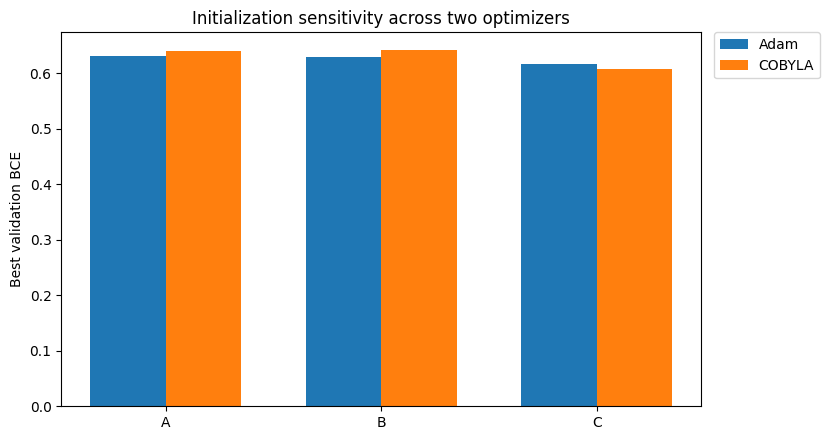

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_binary_dataset(seed=12)
initializations = {
    "A": np.array([0.30, -0.20, 0.10, 0.05]),
    "B": np.array([-0.40, 0.15, 0.60, -0.10]),
    "C": np.array([0.80, -0.60, 0.20, 0.30]),
}

def run_both(initial_weights):
    adam_result = adam_train(
        X_train, y_train, X_val, y_val,
        initial_weights=initial_weights,
        epochs=35,
        batch_size=12,
        learning_rate=0.08,
        seed=23,
    )
    cobyla_result = cobyla_train(
        X_train, y_train, X_val, y_val,
        initial_weights=initial_weights,
        maxiter=45,
        rhobeg=0.5,
        tol=1e-4,
    )

    adam_test = evaluate_classifier(X_test, y_test, adam_result["weights"])
    cobyla_test = evaluate_classifier(X_test, y_test, cobyla_result["weights"])

    return {
        "Adam": {
            "final_val": float(adam_result["val_history"][-1]),
            "best_val": float(np.min(adam_result["val_history"])),
            "test_bce": adam_test["bce"],
            "test_accuracy": adam_test["accuracy"],
            "updates": int(adam_result["steps"]),
        },
        "COBYLA": {
            "final_val": float(cobyla_result["val_history"][-1]),
            "best_val": float(np.min(cobyla_result["val_history"])),
            "test_bce": cobyla_test["bce"],
            "test_accuracy": cobyla_test["accuracy"],
            "updates": int(cobyla_result["iterations"]),
        },
    }

summary = {label: run_both(weights) for label, weights in initializations.items()}

for label, results in summary.items():
    print(label, results)

labels = list(summary.keys())
adam_best = [summary[label]["Adam"]["best_val"] for label in labels]
cobyla_best = [summary[label]["COBYLA"]["best_val"] for label in labels]

x_axis = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8.4, 4.5))
ax.bar(x_axis - width / 2, adam_best, width=width, label="Adam")
ax.bar(x_axis + width / 2, cobyla_best, width=width, label="COBYLA")
ax.set_xticks(x_axis)
ax.set_xticklabels(labels)
ax.set_ylabel("Best validation BCE")
ax.set_title("Initialization sensitivity across two optimizers")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.tight_layout()
plt.show()


This comparison should still be read as a stability study rather than as a universal ranking, but in this run the most visible feature is how similar the two optimizers are. Across all three initializations, the best validation losses of Adam and COBYLA stay very close to one another, and the variation across starts is also modest. That suggests that, for this small variational model and this particular dataset split, both optimizers are being driven toward similarly good regions of parameter space rather than displaying sharply different initialization sensitivity.

The initialization labeled `C` appears slightly more favorable for Adam, but the overall gap remains small compared with the scale of the validation losses themselves. So the main lesson of this figure is not that one optimizer is decisively better, but that under this experimental setup the optimizer choice has a weaker visible effect than one might expect from the algorithmic differences alone. Similar bars do not mean that Adam and COBYLA work in the same way; they only mean that, in this experiment, their best validation losses end up being close. The summary also reminds us that “more updates” and “better validation loss” are not the same statement. Adam typically records many more updates because it works mini-batch by mini-batch, while COBYLA counts a different kind of iteration based on objective probing. That is why optimizer comparisons in QML should keep the evaluation model visible instead of collapsing everything into a single curve.
